### DEM Derivatives
Calcul de toutes les couches terrain dérivées depuis le DEM local (`data/mono_dem.tif`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

from durpy.derivedDem import (
    init_local_engine,
    derive_slope, derive_aspect, derive_curvature, derive_twi,
    derive_flow_accumulation, derive_drainage_density, derive_dist_to_river,
    load_hand, load_runoff, load_dist_to_road,    # chargement depuis fichiers
    load_rain_v2, load_lulc,
)
from durpy.variables import WC_LEGEND, LAYERS

DEM_PATH = "data/mono_dem.tif"
init_local_engine(DEM_PATH)

DEM chargé : (11010, 4500) | ext=[0.687639184, 1.937639284, 6.279305658, 9.337639236]


In [2]:
slope,  ext = derive_slope()
aspect, ext = derive_aspect()
curv,   ext = derive_curvature()
twi,    ext = derive_twi()
facc,   ext = derive_flow_accumulation()
density, ext = derive_drainage_density()
distRiver, ext = derive_dist_to_river()

🗺️  raster enregistré : .\_tmp_dem_pysheds.tif


In [4]:
lulc, ext = load_lulc("data/lulc_esa.tif")
#rain, ext = load_rain_v2("data/chirps_daily_1985_2023.nc")

# ── Chargement depuis fichiers existants (alignement auto sur le DEM) ─────────
hand,     ext = load_hand("data/hand.tif")
runoff,   ext = load_runoff("data/Runoff.tif")
distRoad, ext = load_dist_to_road("data/Roads.tif")

HAND chargé       : min=0.0 m  | max=577.5 m
Runoff chargé     : min=5.8    | max=18.4 mm/an
Dist. routes chargée : min=0 m | max=29854 m


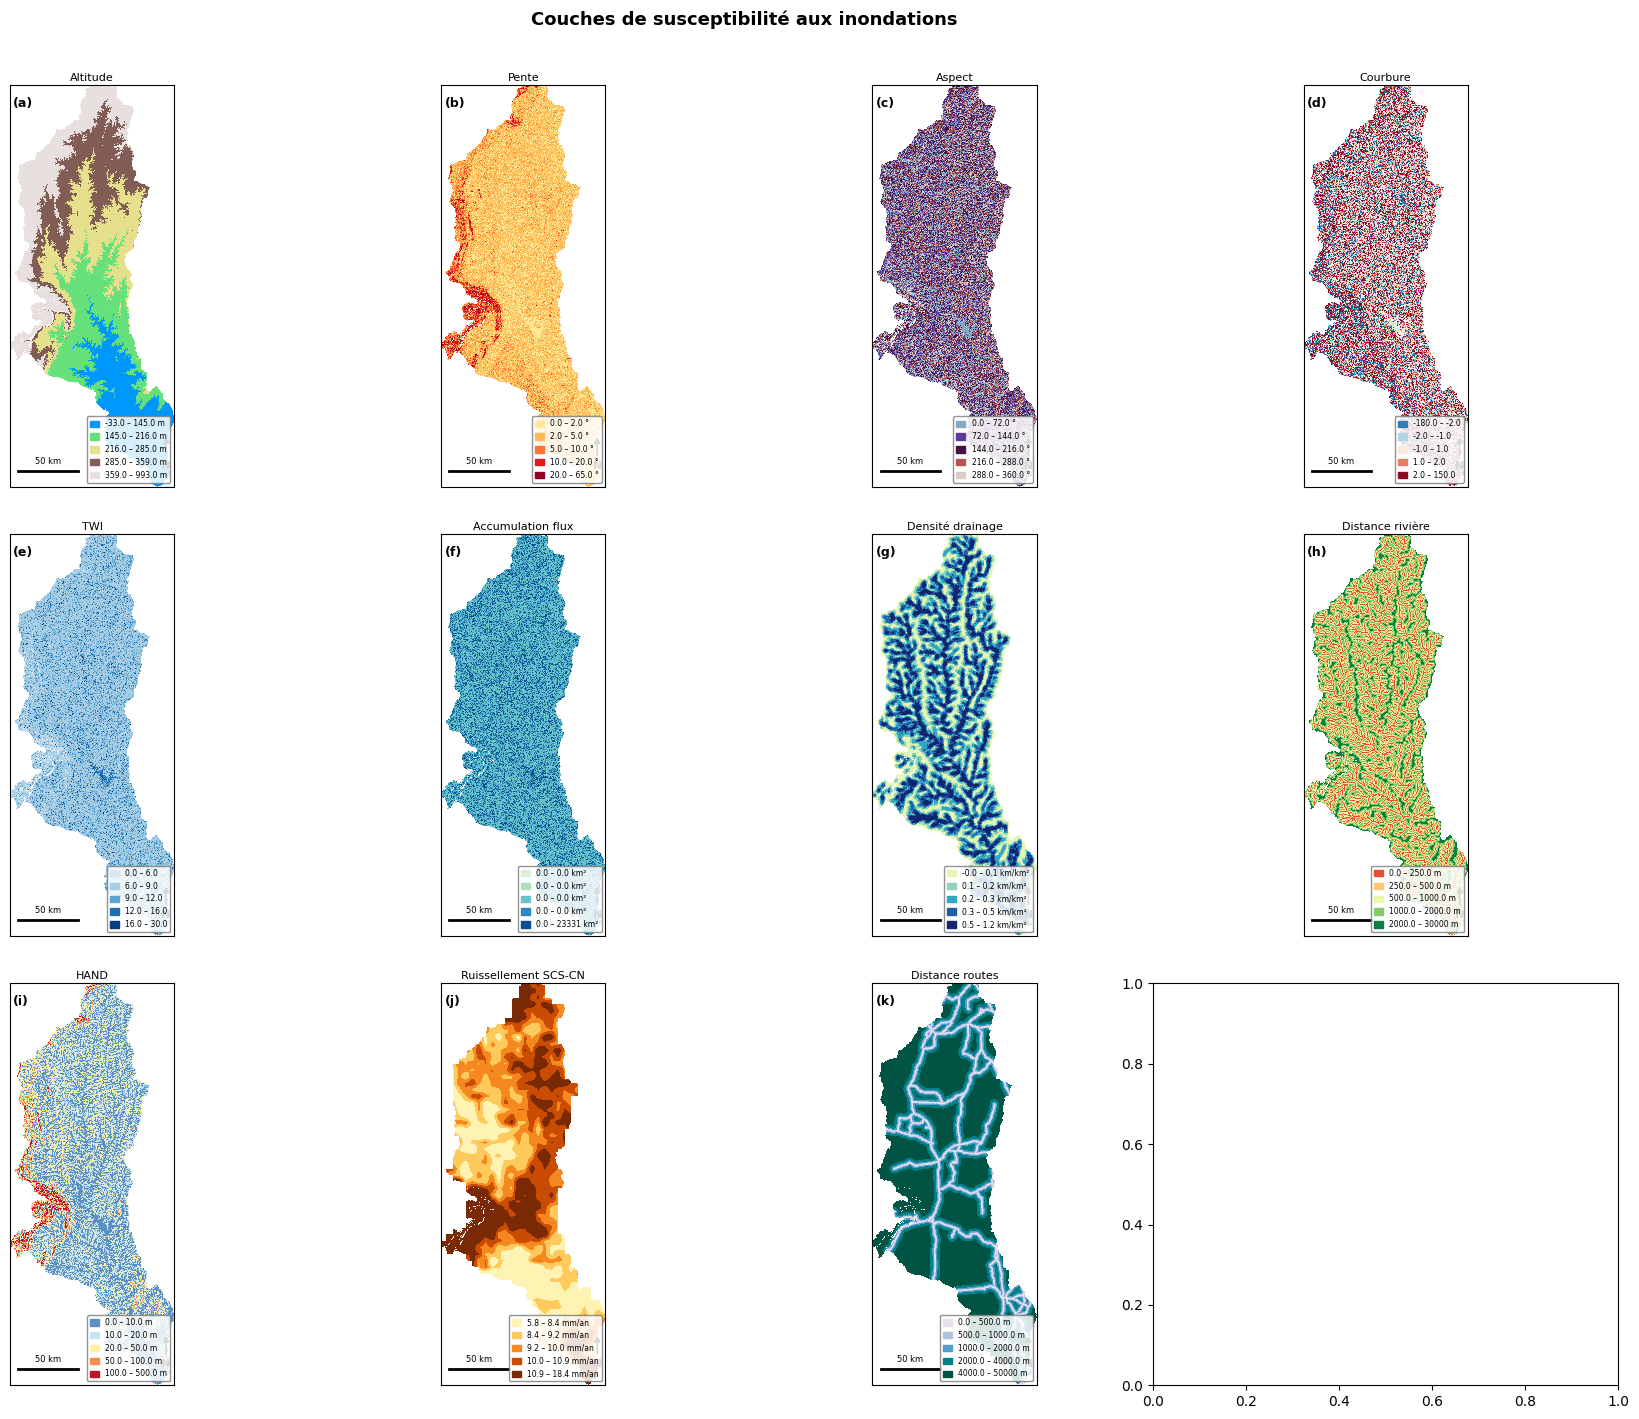

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# HELPER — carte classifiée style article (légende intervalles, flèche N, barre)
# ═══════════════════════════════════════════════════════════════════════════════

def _quantile_breaks(arr, n=5):
    """Seuils quantiles sur valeurs valides."""
    valid = arr[~np.isnan(arr)].ravel()
    return np.percentile(valid, np.linspace(0, 100, n + 1))


def _add_north_arrow(ax):
    ax.annotate("N", xy=(0.95, 0.13), xytext=(0.95, 0.04),
                xycoords="axes fraction", textcoords="axes fraction",
                ha="center", va="bottom", fontsize=8, fontweight="bold",
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.2))


def _add_scale_bar(ax, ext, bar_km=50):
    """Barre d'échelle horizontale en bas à gauche."""
    lon_min, lon_max, lat_min, lat_max = ext
    lat_c   = (lat_min + lat_max) / 2
    deg_per_km = 1 / (111.32 * np.cos(np.radians(lat_c)))
    bar_deg    = bar_km * deg_per_km
    lon_range  = lon_max - lon_min
    x0 = lon_min + 0.05 * lon_range
    x1 = x0 + bar_deg
    y0 = lat_min + 0.04 * (lat_max - lat_min)
    ax.plot([x0, x1], [y0, y0], color="black", lw=2, transform=ax.transData)
    ax.text((x0 + x1) / 2, y0 + 0.012 * (lat_max - lat_min),
            f"{bar_km} km", ha="center", va="bottom", fontsize=6,
            transform=ax.transData)


def plot_classified_layer(ax, arr, ext, title, label,colors=None, n_classes=5,breaks=None, unit=""):
    """
    Affiche une couche raster classifiée (n_classes classes quantiles).

    Parameters
    ----------
    ax       : axes matplotlib
    arr      : array 2D float32
    ext      : [lon_min, lon_max, lat_min, lat_max]
    title    : titre du panneau
    label    : lettre de panneau, ex. "(a)"
    colors   : liste de n_classes couleurs (défaut : YlOrRd)
    n_classes: nombre de classes (défaut 5)
    breaks   : seuils fixes ; si None → quantiles
    unit     : unité pour la légende
    """
    if colors is None:
        colors = plt.cm.YlOrRd(np.linspace(0.15, 0.95, n_classes))

    if breaks is None:
        breaks = _quantile_breaks(arr, n_classes)

    cmap  = ListedColormap(colors)
    norm  = BoundaryNorm(breaks, ncolors=n_classes)
    cmap.set_bad(alpha=0)

    classified = np.digitize(arr, breaks[1:-1])  # 0 .. n_classes-1
    classified = classified.astype("float32")
    classified[np.isnan(arr)] = np.nan

    ax.imshow(classified, cmap=cmap, vmin=0, vmax=n_classes - 1,
              extent=ext, origin="upper", interpolation="nearest")
    ax.set_aspect("equal")

    # Bordure propre
    for spine in ax.spines.values():
        spine.set_edgecolor("black"); spine.set_linewidth(0.8)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)

    # Titre + label
    ax.set_title(title, fontsize=8, pad=3)
    ax.text(0.02, 0.97, label, transform=ax.transAxes,
            fontsize=9, fontweight="bold", va="top")

    # Légende intervalles
    patches = []
    for i in range(n_classes):
        lo = f"{breaks[i]:.1f}" if abs(breaks[i]) < 1e4 else f"{breaks[i]:.0f}"
        hi = f"{breaks[i+1]:.1f}" if abs(breaks[i+1]) < 1e4 else f"{breaks[i+1]:.0f}"
        label_txt = f"{lo} – {hi}" + (f" {unit}" if unit else "")
        patches.append(mpatches.Patch(color=colors[i], label=label_txt))
    ax.legend(handles=patches, loc="lower right", fontsize=5.5,
              framealpha=0.85, edgecolor="grey",
              handlelength=1.2, handleheight=0.9)

    _add_north_arrow(ax)
    _add_scale_bar(ax, ext, bar_km=50)

# ═══════════════════════════════════════════════════════════════════════════════
# VISUALISATION — 13 couches  (3 × 4 = 12 panneaux + 1 vide)
# ═══════════════════════════════════════════════════════════════════════════════
from durpy.variables import LAYERS

elev = LAYERS["elevation"]

LAYER_CFG = [
    # (tableau,    titre,                   label, palette,          unité,     seuils fixes ou None)
    (elev,      "Altitude",              "(a)", "terrain",        "m",      None),
    (slope,     "Pente",                 "(b)", "YlOrRd",         "°",      [0,2,5,10,20,65]),
    (aspect,    "Aspect",                "(c)", "twilight",       "°",      [0,72,144,216,288,360]),
    (curv,      "Courbure",              "(d)", "RdBu_r",         "",       None),
    (twi,       "TWI",                   "(e)", "Blues",          "",       [0,6,9,12,16,30]),
    (facc,      "Accumulation flux",     "(f)", "GnBu",           "km²",    None),
    (density,   "Densité drainage",      "(g)", "YlGnBu",         "km/km²", None),
    (distRiver, "Distance rivière",      "(h)", "RdYlGn",         "m",      [0,250,500,1000,2000,30000]),
    (hand,      "HAND",                  "(i)", "RdYlBu_r",       "m",      [0,10,20,50,100,500]),
    (runoff,    "Ruissellement SCS-CN",  "(j)", "YlOrBr",         "mm/an",  None),
    (distRoad,  "Distance routes",       "(k)", "PuBuGn",         "m",      [0,500,1000,2000,4000,50000]),
    #(rain,      "Pluie annuelle",        "(l)", "YlGnBu",         "mm/an",  None),
]

fig, axes = plt.subplots(3, 4, figsize=(18, 14))
axes_flat = axes.flat

for ax, (arr, title, lbl, palette, unit, custom_breaks) in zip(axes_flat, LAYER_CFG):
    if isinstance(palette, str):
        n = 5
        cmap_obj = plt.get_cmap(palette)
        cols = [cmap_obj(v) for v in np.linspace(0.15, 0.95, n)]
    else:
        cols = palette
        n = len(palette)

    plot_classified_layer(ax, arr, ext, title=title, label=lbl, colors=cols, n_classes=n,
                          breaks=custom_breaks, unit=unit)

# Cache le dernier panneau vide
#list(axes_flat)[-1].set_visible(False)

plt.suptitle("Couches de susceptibilité aux inondations", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(h_pad=2.5, w_pad=1.5)
plt.show()

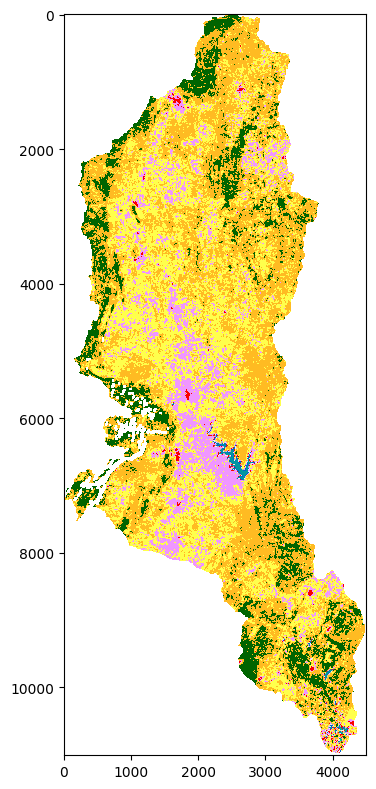

In [7]:
lulc, ext = load_lulc("data/lulc_esa.tif")

codes  = sorted(WC_LEGEND.keys())
colors = [WC_LEGEND[c][1] for c in codes]
cmap   = ListedColormap(colors)
cmap.set_bad(alpha=0)

fig, ax = plt.subplots(figsize=(4, 8))
im = ax.imshow(lulc, cmap=cmap, vmin=codes[0]-5, vmax=codes[-1]+5)
patches = [Patch(color=WC_LEGEND[c][1], label=WC_LEGEND[c][0]) for c in codes]
#ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
#ax.set_title("Land Use / Land Cover"); ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import os
import rasterio
import numpy as np
from rasterio.transform import from_bounds
from durpy.variables import LAYERS

OUT_DIR = "output/qgis"
os.makedirs(OUT_DIR, exist_ok=True)

lon_min, lon_max, lat_min, lat_max = ext

def export_tif(arr, name, nodata=-9999.0):
    h, w      = arr.shape
    transform = from_bounds(lon_min, lat_min, lon_max, lat_max, w, h)
    data      = np.where(np.isfinite(arr), arr, nodata).astype("float32")
    path      = os.path.join(OUT_DIR, f"{name}.tif")
    with rasterio.open(
        path, "w", driver="GTiff",
        height=h, width=w, count=1, dtype="float32",
        crs="EPSG:4326", transform=transform,
        nodata=nodata, compress="lzw",
    ) as dst:
        dst.write(data, 1)
    print(f"  ✓  {name}.tif   min={float(np.nanmin(arr)):.2f}  max={float(np.nanmax(arr)):.2f}")

print(f"Export → {os.path.abspath(OUT_DIR)}\n")

layers_to_export = {
    "elevation":        LAYERS["elevation"],
    "slope":            slope,
    "aspect":           aspect,
    "curvature":        curv,
    "twi":              twi,
    "flow_accumulation":facc,
    "drainage_density": density,
    "dist_to_river":    distRiver,
    "hand":             hand,
    "runoff":           runoff,
    "dist_to_road":     distRoad,
    "worldcover":       lulc,
}

for name, arr in layers_to_export.items():
    export_tif(arr, name)

print(f"\n{len(layers_to_export)} couches exportées → {os.path.abspath(OUT_DIR)}")


In [ ]:
"""
fig, ax = plt.subplots(figsize=(4, 8))
im = ax.imshow(rain, cmap="YlGnBu",
               vmin=np.nanpercentile(rain, 2),
               vmax=np.nanpercentile(rain, 98))
ax.set_title("Pluie annuelle moyenne")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, label="mm/an")
plt.tight_layout()
plt.show()
"""

### AHP for Flood Risk Mapping
Workflow complet : normalisation → reclassification → poids → FIPS → zones de risque.

In [8]:
from durpy.ahp import (
    normalize_all, compute_scores, compute_weights,
    compute_flood_index, classify_flood_index, sensitivity_analysis,
)
from durpy.ahp_config import RECLASS, AHP_CRITERIA, AHP_PAIRS, AHP_INCLUDE, NORM_KEYS
from durpy.variables import LAYERS, SCORE_LEGEND

In [9]:
# --- ETAPE 1 : Normalisation 0-1 ---
# Methodes disponibles : minmax | robust | zscore | fuzzy_linear | fuzzy_sigmoidal
NORM_METHOD = "minmax"

print("Normalisation des couches :", NORM_KEYS)
stats_df = normalize_all(NORM_KEYS, method=NORM_METHOD)
print("Statistiques :")
print(stats_df.to_string(index=False))


Normalisation des couches : ['elevation', 'slope', 'curvature', 'dist_to_river', 'drainage_density', 'twi', 'flow_accumulation', 'hand', 'runoff', 'dist_to_road']
  ✓ norm_elevation
  ✓ norm_slope
  ✓ norm_curvature
  ✓ norm_dist_to_river
  ✓ norm_drainage_density
  ✓ norm_twi
  ✓ norm_flow_accumulation
  ✓ norm_hand
  ✓ norm_runoff
  ✓ norm_dist_to_road
Statistiques :
        criterion       min        max      mean       std method
        elevation  -33.0000   993.0000  261.2402  146.1052 minmax
            slope    0.0000    63.9490    3.3326    3.3070 minmax
        curvature -180.0000   150.0000    0.0006    3.0426 minmax
    dist_to_river    0.0000  5629.6191  973.5883  713.8777 minmax
 drainage_density   -0.0000     1.1781    0.2921    0.2162 minmax
              twi   -1.4021    27.3493    8.6254    2.3516 minmax
flow_accumulation    0.0010 23331.1719    7.6257  323.9386 minmax
             hand    0.0000   577.5296   17.7362   26.3419 minmax
           runoff    5.7759    18.

In [10]:
# --- ETAPE 2 : Reclassification -> scores 1-5 ---
# RECLASS_INPUT = "raw"       -> utilise les couches brutes
# RECLASS_INPUT = "normalized" -> utilise les couches normalisees
RECLASS_INPUT = "raw"
use_norm = RECLASS_INPUT == "normalized"

print("Reclassification des facteurs :")
SCORES = compute_scores(RECLASS, AHP_INCLUDE, use_norm=use_norm)
print(f"{len(SCORES)} facteurs scores : {list(SCORES.keys())}")


Reclassification des facteurs :
  ✓ score_elevation
  ✓ score_slope
  ✓ score_aspect
  ✓ score_curvature
  ✓ score_dist_to_river
  ✓ score_drainage_density
  ✓ score_twi
  ✓ score_flow_accumulation
  ✓ score_worldcover
  ✓ score_hand
  ✓ score_runoff
  ✓ score_dist_to_road
12 facteurs scores : ['elevation', 'slope', 'aspect', 'curvature', 'dist_to_river', 'drainage_density', 'twi', 'flow_accumulation', 'worldcover', 'hand', 'runoff', 'dist_to_road']


In [11]:
# --- ETAPE 3 : Poids AHP (matrice de Saaty) ---
# Si CR > 0.10 : ajuster AHP_PAIRS dans durpy/ahp_config.py
weights = compute_weights(AHP_PAIRS, AHP_CRITERIA, AHP_INCLUDE, SCORES)


Critères actifs (12) : elevation, slope, aspect, curvature, dist_to_river, drainage_density, twi, flow_accumulation, worldcover, hand, runoff, dist_to_road
λ_max = 12.256 | CI = 0.0233 | RI = 1.48 | CR = 0.0157 → ✅ consistant (CR < 0.10)
 rank         criterion  weight_eigenvector  weight_RGMM  weight_%
    1              hand              0.1535       0.1535     15.35
    2               twi              0.1499       0.1515     14.99
    3 flow_accumulation              0.1424       0.1430     14.24
    4     dist_to_river              0.1401       0.1400     14.01
    5            runoff              0.0935       0.0931      9.35
    6             slope              0.0922       0.0914      9.22
    7         elevation              0.0725       0.0723      7.25
    8  drainage_density              0.0503       0.0501      5.03
    9      dist_to_road              0.0358       0.0357      3.58
   10        worldcover              0.0315       0.0315      3.15
   11         curvature  

In [12]:
# --- ETAPE 4 : Indice de risque (FIPS) ---
fips = compute_flood_index(SCORES, weights)
print(f"FIPS : min={float(np.nanmin(fips)):.3f} | max={float(np.nanmax(fips)):.3f} | mean={float(np.nanmean(fips)):.3f}")


FIPS : min=0.555 | max=5.000 | mean=2.954


In [13]:
# --- ETAPE 5 : Classification en zones de risque ---
# method = "equal" (seuils fixes 1.8/2.6/3.4/4.2) ou "quantile"
zones, breaks = classify_flood_index(fips, method="equal")
LAYERS["flood_risk"] = zones


Seuils zones : [1.8, 2.6, 3.4, 4.2]


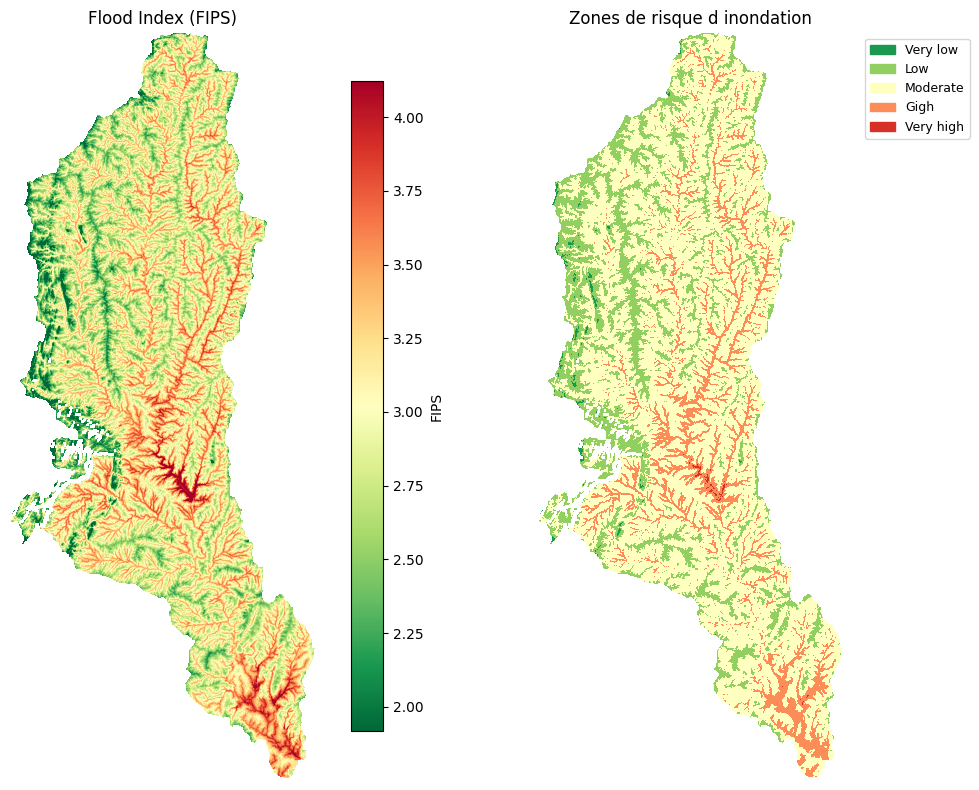

In [ ]:
# --- ETAPE 6 : Visualisation FIPS + zones ---
zone_colors = ["#1a9850", "#91cf60", "#ffffbf", "#fc8d59", "#d73027"]
zone_labels = ["Very low", "Low", "Moderate", "Gigh", "Very high"]
cmap_zones = ListedColormap(zone_colors)
cmap_zones.set_bad(alpha=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# FIPS continu
im0 = axes[0].imshow(fips, cmap="RdYlGn_r", vmin=np.nanpercentile(fips, 2),
                     vmax=np.nanpercentile(fips, 98))
axes[0].set_title("Flood Index (FIPS)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, label="FIPS")

# Zones discretes
im1 = axes[1].imshow(zones, cmap=cmap_zones, vmin=0.5, vmax=5.5)
axes[1].set_title("Flood susceptibility map")
axes[1].axis("off")
patches = [Patch(color=zone_colors[i], label=zone_labels[i]) for i in range(5)]
axes[1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()


Sensibilite par facteur (MAD = ecart moyen absolu sur le FIPS) :
 rank         criterion  weight_%  MAD_FIPS
    1              hand     15.35    0.2195
    2 flow_accumulation     14.24    0.2143
    3     dist_to_river     14.01    0.1342
    4            runoff      9.35    0.1256
    5             slope      9.22    0.1249
    6               twi     14.99    0.1242
    7         elevation      7.25    0.0862
    8      dist_to_road      3.58    0.0551
    9  drainage_density      5.03    0.0550
   10         curvature      2.40    0.0328
   11        worldcover      3.15    0.0241
   12            aspect      1.42    0.0187


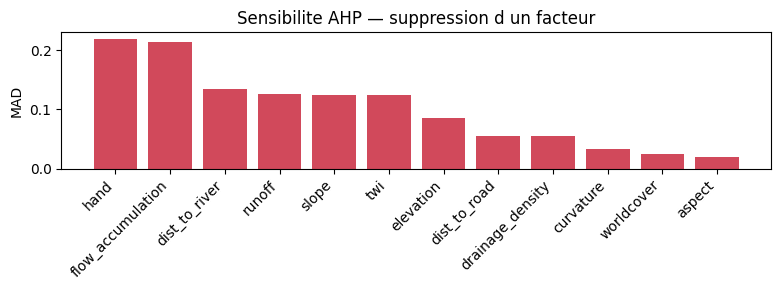

In [15]:
# --- ETAPE 7 : Analyse de sensibilite ---
sens_df = sensitivity_analysis(SCORES, weights, fips)
print("Sensibilite par facteur (MAD = ecart moyen absolu sur le FIPS) :")
print(sens_df.to_string(index=False))

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 3))
plt.bar(sens_df["criterion"], sens_df["MAD_FIPS"], color="#d1495b")
plt.xticks(rotation=45, ha="right")
plt.ylabel("MAD")
plt.title("Sensibilite AHP — suppression d un facteur")
plt.tight_layout()
plt.show()


In [ ]:
FORAGES_PATH = "data/ForagesMono.csv"          

df = pd.read_csv(FORAGES_PATH)             
df = df.rename(columns={"xCoord": "lon", "yCoord": "lat"})   

LON_COL = "lon" 
LAT_COL = "lat" 

print(f"{len(df)} forages chargés | colonnes : {list(df.columns)}")
print(df[[LON_COL, LAT_COL]].describe())

In [26]:
def load_forages(path, sep=",", lon_col="xCoord", lat_col="yCoord", source_name=None):
    """Charge un fichier CSV de forages et extrait la zone de risque à chaque point."""
    d = pd.read_csv(path, sep=sep)
    d = d.rename(columns={lon_col: "lon", lat_col: "lat"})
    d["source"] = source_name or path

    lon_min, lon_max, lat_min, lat_max = ext
    h, w = zones.shape

    def to_px(lon, lat):
        col = int((lon - lon_min) / (lon_max - lon_min) * (w - 1))
        row = int((lat_max - lat) / (lat_max - lat_min) * (h - 1))
        return row, col

    rs, cs = zip(*[to_px(lo, la) for lo, la in zip(d["lon"], d["lat"])])
    rs, cs = np.array(rs), np.array(cs)

    in_b = (rs >= 0) & (rs < h) & (cs >= 0) & (cs < w)
    rs_s = np.clip(rs, 0, h - 1)
    cs_s = np.clip(cs, 0, w - 1)

    d["zone_risque"]  = np.where(in_b, zones[rs_s, cs_s], np.nan)
    d["fips"]         = np.where(in_b, fips[rs_s,  cs_s], np.nan)
    d["in_bounds"]    = in_b
    return d

zone_labels = {1: "Very low", 2: "Low", 3: "Moderate",
               4: "High", 5: "Very high"}

df_mono = load_forages("data/ForagesMono.csv", sep=",",  source_name="Benin")
df_togo = load_forages("data/Togo.csv",        sep=",",  source_name="Togo")

for label, df_ in [("ForagesMono", df_mono), ("Togo", df_togo)]:
    n_in  = df_["in_bounds"].sum()
    n_out = (~df_["in_bounds"]).sum()
    print(f"\n── {label} : {len(df_)} forages ({n_in} dans l'emprise, {n_out} hors emprise)")
    counts = df_["zone_risque"].map(zone_labels).value_counts().sort_index()
    print(counts.to_string())


── ForagesMono : 1763 forages (1314 dans l'emprise, 449 hors emprise)
zone_risque
High         25
Low         571
Moderate    495
Very low      8

── Togo : 1558 forages (1367 dans l'emprise, 191 hors emprise)
zone_risque
High         63
Low         693
Moderate    438
Very low     81


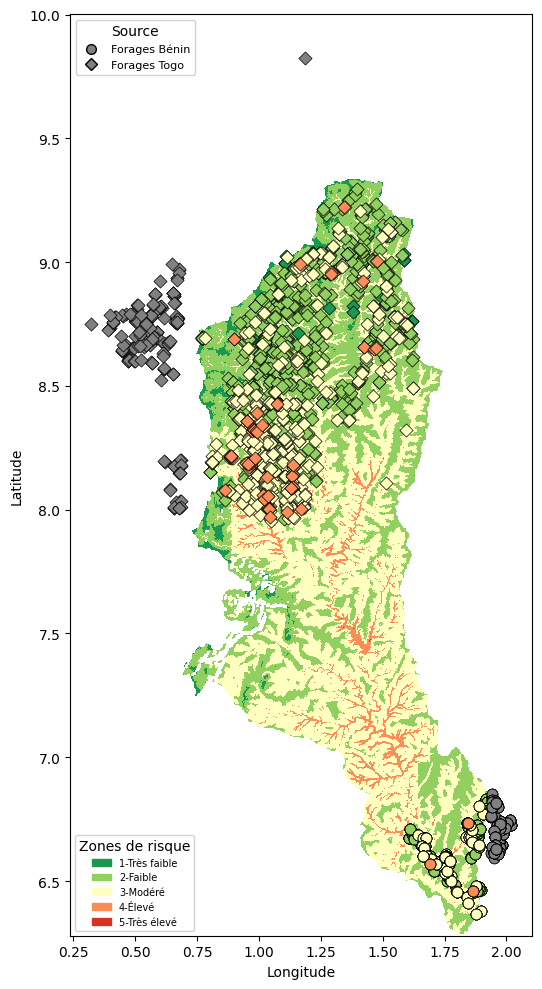

Exporté → data/ForagesMono_risque.csv
Exporté → data/Togo_risque.csv


In [ ]:
zone_colors = ["#1a9850", "#91cf60", "#ffffbf", "#fc8d59", "#d73027"]
cmap_zones  = ListedColormap(zone_colors)
cmap_zones.set_bad(alpha=0)

# Configurations visuelles par source
DATASETS = [
    {"df": df_mono, "marker": "o", "size": 60,  "label": "ForagesMono"},
    {"df": df_togo, "marker": "D", "size": 45,  "label": "Togo"},
]

fig, ax = plt.subplots(figsize=(7, 10))

# Fond : zones de risque
ax.imshow(zones, cmap=cmap_zones, vmin=0.5, vmax=5.5,
          extent=[lon_min, lon_max, lat_min, lat_max], origin="upper")

# Forages — une série par (source × zone)
for ds in DATASETS:
    df_  = ds["df"]
    mkr  = ds["marker"]
    sz   = ds["size"]
    src  = ds["label"]
    for zone_id, color in zip([1, 2, 3, 4, 5], zone_colors):
        mask = df_["zone_risque"] == zone_id
        if mask.any():
            ax.scatter(df_.loc[mask, "lon"], df_.loc[mask, "lat"],
                       c=color, edgecolors="black", linewidths=0.5,
                       s=sz, marker=mkr, zorder=5)
    # Forages hors emprise
    hors = ~df_["in_bounds"]
    if hors.any():
        ax.scatter(df_.loc[hors, "lon"], df_.loc[hors, "lat"],
                   c="grey", edgecolors="black", linewidths=0.5,
                   s=sz, marker=mkr, zorder=5)

# ── Légende 1 : zones de risque (couleurs)
patches_zones = [mpatches.Patch(color=zone_colors[i], label=list(zone_labels.values())[i])
                 for i in range(5)]                   #label=f"Zone {i+1} — {list(zone_labels.values())[i]}"
leg1 = ax.legend(handles=patches_zones, title="Zones de risque",
                 loc="lower left", fontsize=7, framealpha=0.85)
ax.add_artist(leg1)

# ── Légende 2 : source des forages (forme du marqueur)
import matplotlib.lines as mlines
handles_src = [
    mlines.Line2D([], [], color="grey", marker="o", linestyle="None",
                  markersize=7, markeredgecolor="black", label="Forages Bénin"),
    mlines.Line2D([], [], color="grey", marker="D", linestyle="None",
                  markersize=6, markeredgecolor="black", label="Forages Togo"),
]
ax.legend(handles=handles_src, title="Source", loc="upper left",
          fontsize=8, framealpha=0.85)

#ax.set_title("Forages — Zones de risque d'inondation")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

"""
# Export
for ds in DATASETS:
    out = f"data/{ds['label']}_risque.csv"
    ds["df"].drop(columns=["in_bounds"]).to_csv(out, index=False)
    print(f"Exporté → {out}")
"""

In [ ]:
out_path = "data/forages_risque.csv"
df.drop(columns=["row_px", "col_px"]).to_csv(out_path, index=False)
print(f"\nRésultats exportés → {out_path}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from durpy.ahp_config import AHP_CRITERIA, AHP_PAIRS

# ── Construction de la matrice 13×13 ─────────────────────────────────────────
n      = len(AHP_CRITERIA)
matrix = np.ones((n, n))
for (i, j), v in AHP_PAIRS.items():
    matrix[i, j] = v
    matrix[j, i] = 1.0 / v

# ── Poids (vecteur propre dominant) ──────────────────────────────────────────
eigenvalues, eigenvectors = np.linalg.eig(matrix)
max_idx    = np.argmax(np.real(eigenvalues))
weights    = np.real(eigenvectors[:, max_idx])
weights   /= weights.sum()
lambda_max = np.real(eigenvalues[max_idx])

RI_TABLE = {3:0.58, 4:0.90, 5:1.12, 6:1.24, 7:1.32, 8:1.41,
            9:1.45, 10:1.49, 11:1.51, 12:1.54, 13:1.56}
ri = RI_TABLE.get(n, 1.56)
ci = (lambda_max - n) / (n - 1)
cr = ci / ri

print(f"n={n} | λ_max={lambda_max:.4f} | CI={ci:.4f} | RI={ri} | CR={cr:.4f} "
      + ("✅ consistant" if cr < 0.10 else "⚠️  INCOHÉRENT — ajuster AHP_PAIRS"))

labels_short = [c.replace("_", "\n") for c in AHP_CRITERIA]

# ═══════════════════════════════════════════════════════════════════════════════
# Figure 1 — Heatmap de la matrice de Saaty
# ═══════════════════════════════════════════════════════════════════════════════
log_m = np.log2(matrix)   # log₂ pour mieux voir les petites/grandes valeurs
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(log_m, ax=ax,
            xticklabels=labels_short, yticklabels=labels_short,
            cmap="RdBu_r", center=0, annot=False,
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "log₂(aᵢⱼ)", "shrink": 0.7})
ax.set_title("Matrice de comparaison par paires AHP (log₂)", fontsize=12, pad=10)
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# Figure 2 — Poids AHP triés (barh + annotations)
# ═══════════════════════════════════════════════════════════════════════════════
order   = np.argsort(weights)
sorted_labels  = [AHP_CRITERIA[i].replace("_", " ") for i in order]
sorted_weights = weights[order]

COLORS = ["#d73027","#fc8d59","#fee090","#e0f3f8","#91bfdb",
          "#4575b4","#313695","#1a9641","#31a354","#78c679",
          "#c2e699","#ffffcc","#969696"]
bar_colors = [COLORS[i % len(COLORS)] for i in range(n)]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(sorted_labels, sorted_weights * 100,
               color=bar_colors, edgecolor="white", height=0.7)
for bar, val in zip(bars, sorted_weights * 100):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=8)

ax.set_xlabel("Poids AHP (%)", fontsize=10)
ax.set_title("Importance relative des facteurs de susceptibilité\n"
             f"(CR = {cr*100:.2f}% — {'consistant ✅' if cr < 0.10 else 'incohérent ⚠️'})",
             fontsize=11)
ax.axvline(100/n, color="grey", linestyle="--", lw=1, alpha=0.6,
           label=f"Poids uniforme ({100/n:.1f}%)")
ax.legend(fontsize=8)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()